### Dispersion Images

In [1]:
# Import necessary dependencies
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('..')
from src.plot import plot_fv_panel, plot_fv_with_pick
from src.utils import parse_ncf_filename, fv_filter

#### 1. Path setup

In [2]:
# Define NCF paths
ncf_raw     = '../data/ncf_raw/20210927_000000_cc_080.npy'
ncf_daily   = '../data/ncf_stacks/daily/20210927_cc_080_daily.npy'
ncf_weekly  = '../data/ncf_stacks/7d/20210927_cc_080_7d.npy'
# ncf_biweekly  = '../data/ncf_stacks/15d/20210927_cc_080_15d.npy'

base = '20210927_cc_080_7d'

In [3]:
# Extract parameters
_, vs, window = parse_ncf_filename(ncf_daily)

In [4]:
# Load NCF data and stacks
ncf_raw_ = np.load(ncf_raw)
ncf_daily_ = np.load(ncf_daily)
ncf_weekly_ = np.load(ncf_weekly)
# ncf_biweekly_ = np.load(ncf_biweekly)

In [5]:
# Load dispersion images
fv = np.load(f'../results/dispersion/7d/VS_{vs}/{base}_fv_panel.npy')
f_axis = np.load(f'../results/dispersion/7d/VS_{vs}/{base}_f_axis.npy')
v_axis = np.load(f'../results/dispersion/7d/VS_{vs}/{base}_v_axis.npy')
pick = np.load(f'../results/dispersion/7d/VS_{vs}/{base}_pick.npy')

In [6]:
# f-v filter settings
P_filt, f_filt, v_filt = fv_filter(
    fv,
    f_axis,
    v_axis,
    fmin=1.0, fmax=10.0,
    vmin=200.0, vmax=2000.0,
    normalize="per_f",
    denoise="median",
    denoise_size=3,
    )

#### 2. Dispersion Images

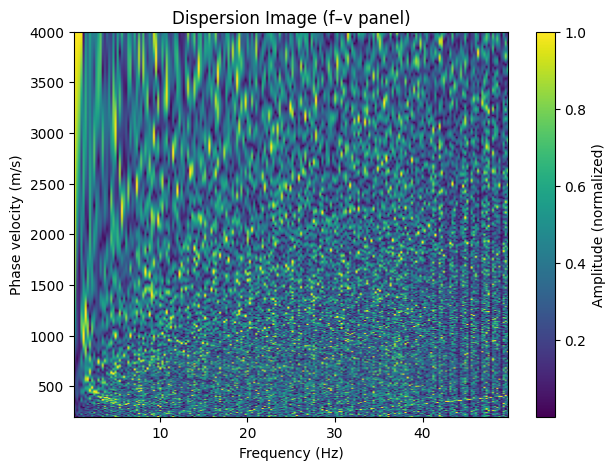

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'Dispersion Image (f–v panel)'}, xlabel='Frequency (Hz)', ylabel='Phase velocity (m/s)'>)

In [7]:
# 1. f-v panel
plot_fv_panel(fv, f_axis, v_axis)

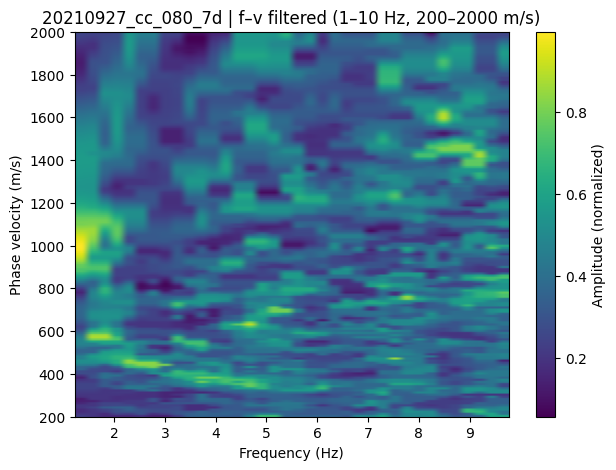

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': '20210927_cc_080_7d | f–v filtered (1–10 Hz, 200–2000 m/s)'}, xlabel='Frequency (Hz)', ylabel='Phase velocity (m/s)'>)

In [8]:
# 2. Filtered f-v panel
plot_fv_panel(P_filt, f_filt, v_filt, title=f"{base} | f–v filtered (1–10 Hz, 200–2000 m/s)")

#### 2. Dispersion Images

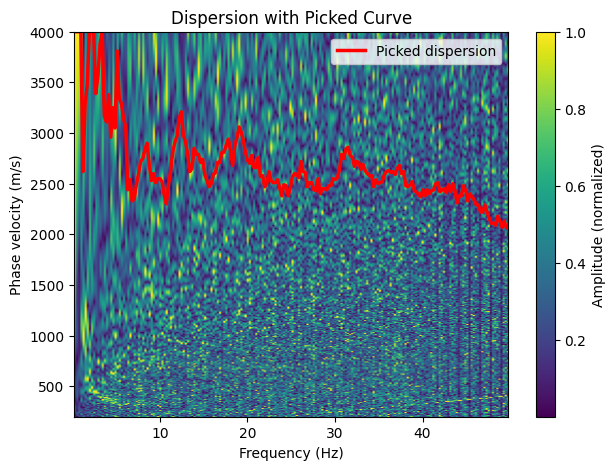

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'Dispersion with Picked Curve'}, xlabel='Frequency (Hz)', ylabel='Phase velocity (m/s)'>)

In [9]:
# f-v + pick
plot_fv_with_pick(fv, f_axis, v_axis, pick)